In [1]:
import os
import random
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

In [2]:
# 1. THIẾT LẬP ĐƯỜNG DẪN & CÂN BẰNG DỮ LIỆU
import os

print("🔍 Đang dò tìm thư mục dữ liệu...")
ROOT_DATA_DIR = ""
for root, dirs, files in os.walk('/kaggle/input'):
    if 'train' in dirs and 'val' in dirs:
        ROOT_DATA_DIR = root
        print(f"✅ {ROOT_DATA_DIR}")
        break

if not ROOT_DATA_DIR:
    raise FileNotFoundError("❌ Không tìm thấy thư mục 'train' và 'val'.")

TRAIN_DIR = os.path.join(ROOT_DATA_DIR, 'train')
VAL_DIR = os.path.join(ROOT_DATA_DIR, 'val')

def get_balanced_dataset(data_dir, ratio=2.0):
    yawn_dir = os.path.join(data_dir, 'yawn')
    no_yawn_dir = os.path.join(data_dir, 'no_yawn')
    
    yawn_files = [os.path.join(yawn_dir, f) for f in os.listdir(yawn_dir)]
    no_yawn_files = [os.path.join(no_yawn_dir, f) for f in os.listdir(no_yawn_dir)]
    
    # Trộn ngẫu nhiên kho ảnh Bình thường (Hard Negatives)
    import random
    random.seed(42)
    random.shuffle(no_yawn_files)
    
    # Lấy số lượng No_Yawn theo đúng tỷ lệ (mặc định 1 Ngáp : 2 Bình thường)
    target_no_yawn_count = int(len(yawn_files) * ratio)
    no_yawn_balanced = no_yawn_files[:target_no_yawn_count]
    
    print(f"[{os.path.basename(data_dir).upper()}] Dữ liệu đưa vào Train: {len(yawn_files)} Yawn | {len(no_yawn_balanced)} No Yawn")
    
    dataset_items = [(f, 1) for f in yawn_files] + [(f, 0) for f in no_yawn_balanced]
    random.shuffle(dataset_items)
    return dataset_items

print("⚖️ ĐANG RÚT TRÍCH VÀ CÂN BẰNG DỮ LIỆU...")
train_items = get_balanced_dataset(TRAIN_DIR, ratio=2.0) 
val_items = get_balanced_dataset(VAL_DIR, ratio=2.0)

🔍 Đang dò tìm thư mục dữ liệu...
✅ /kaggle/input/notebooks/xunctrn/yawdd-cleaned/YawDD_Ultimate_V4
⚖️ ĐANG RÚT TRÍCH VÀ CÂN BẰNG DỮ LIỆU...
[TRAIN] Dữ liệu đưa vào Train: 1901 Yawn | 3802 No Yawn
[VAL] Dữ liệu đưa vào Train: 440 Yawn | 880 No Yawn


In [3]:
# 2. KHỞI TẠO DATASET & DATA AUGMENTATION
class MouthDataset(Dataset):
    def __init__(self, items, transform=None):
        self.items = items
        self.transform = transform

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        img_path, label = self.items[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label

# Tăng cường dữ liệu (Augmentation)
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5), # Lật ảnh ngẫu nhiên
    transforms.RandomRotation(10),          # Xoay nghiêng đầu
    transforms.ColorJitter(brightness=0.2, contrast=0.2), # Đổi độ sáng giả lập ánh sáng cabin
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_loader = DataLoader(MouthDataset(train_items, train_transform), batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(MouthDataset(val_items, val_transform), batch_size=32, shuffle=False, num_workers=2)

In [4]:
# 3. XÂY DỰNG MÔ HÌNH MOBILENET-V2
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n🚀 Đang khởi động GPU: {device}")

model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
num_ftrs = model.classifier[1].in_features
model.classifier = nn.Sequential(
    nn.Dropout(p=0.5),
    nn.Linear(num_ftrs, 2)
)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)


🚀 Đang khởi động GPU: cuda
Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 115MB/s] 


In [5]:
# 4. HUẤN LUYỆN 
num_epochs = 30
best_acc = 0.0
best_val_loss = float('inf') # Biến theo dõi Loss tốt nhất cho Early Stopping

# Cấu hình Early Stopping
early_stopping_patience = 5
epochs_no_improve = 0

history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in range(num_epochs):
    print(f'\nEpoch {epoch+1}/{num_epochs} ' + '-' * 15)
    
    # In ra Learning rate hiện tại để theo dõi Scheduler hoạt động
    current_lr = optimizer.param_groups[0]['lr']
    print(f"👉 Learning Rate hiện tại: {current_lr:.6f}")

    for phase in ['train', 'val']:
        if phase == 'train':
            model.train()
            dataloader = train_loader
        else:
            model.eval()
            dataloader = val_loader

        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in tqdm(dataloader, desc=f"{phase.capitalize()}"):
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()

            with torch.set_grad_enabled(phase == 'train'):
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                if phase == 'train':
                    loss.backward()
                    optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / len(dataloader.dataset)
        epoch_acc = (running_corrects.double() / len(dataloader.dataset)).item()

        print(f'{phase.capitalize()} Loss: {epoch_loss:.4f} - Accuracy: {epoch_acc:.4f}')

        if phase == 'train':
            history['train_loss'].append(epoch_loss)
            history['train_acc'].append(epoch_acc)
        else:
            history['val_loss'].append(epoch_loss)
            history['val_acc'].append(epoch_acc)
            
            # Kích hoạt Scheduler dựa trên Val Loss
            scheduler.step(epoch_loss)

            # LOGIC LƯU MODEL & EARLY STOPPING
            if epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())
                torch.save(best_model_wts, 'best_yawn_ultimate.pt')
                print("🌟 Đã lưu trọng số tốt nhất (theo Accuracy)!")
            
            # Theo dõi Val Loss cho Early Stopping
            if epoch_loss < best_val_loss:
                best_val_loss = epoch_loss
                epochs_no_improve = 0 # Reset bộ đếm
            else:
                epochs_no_improve += 1
                print(f"⚠️ Val Loss không cải thiện ({epochs_no_improve}/{early_stopping_patience})")

    # Kích hoạt Early Stopping
    if epochs_no_improve >= early_stopping_patience:
        print(f"\n🛑 EARLY STOPPING KÍCH HOẠT! Mô hình ngừng học tại Epoch {epoch+1}.")
        break

print(f'\n🏆 HOÀN TẤT HUẤN LUYỆN! Độ chính xác Val cao nhất: {best_acc:.4f}')


Epoch 1/30 ---------------
👉 Learning Rate hiện tại: 0.000100


Train: 100%|██████████| 179/179 [00:31<00:00,  5.60it/s]


Train Loss: 0.2266 - Accuracy: 0.9148


Val: 100%|██████████| 42/42 [00:06<00:00,  6.84it/s]


Val Loss: 0.1454 - Accuracy: 0.9356
🌟 Đã lưu trọng số tốt nhất (theo Accuracy)!

Epoch 2/30 ---------------
👉 Learning Rate hiện tại: 0.000100


...

Val Loss: 0.1976 - Accuracy: 0.9341
⚠️ Val Loss không cải thiện (4/5)

Epoch 9/30 ---------------
👉 Learning Rate hiện tại: 0.000050


Train: 100%|██████████| 179/179 [00:22<00:00,  7.80it/s]


Train Loss: 0.0161 - Accuracy: 0.9953


Val: 100%|██████████| 42/42 [00:02<00:00, 16.55it/s]

Val Loss: 0.1623 - Accuracy: 0.9424
⚠️ Val Loss không cải thiện (5/5)

🛑 EARLY STOPPING KÍCH HOẠT! Mô hình ngừng học tại Epoch 9.

🏆 HOÀN TẤT HUẤN LUYỆN! Độ chính xác Val cao nhất: 0.9705


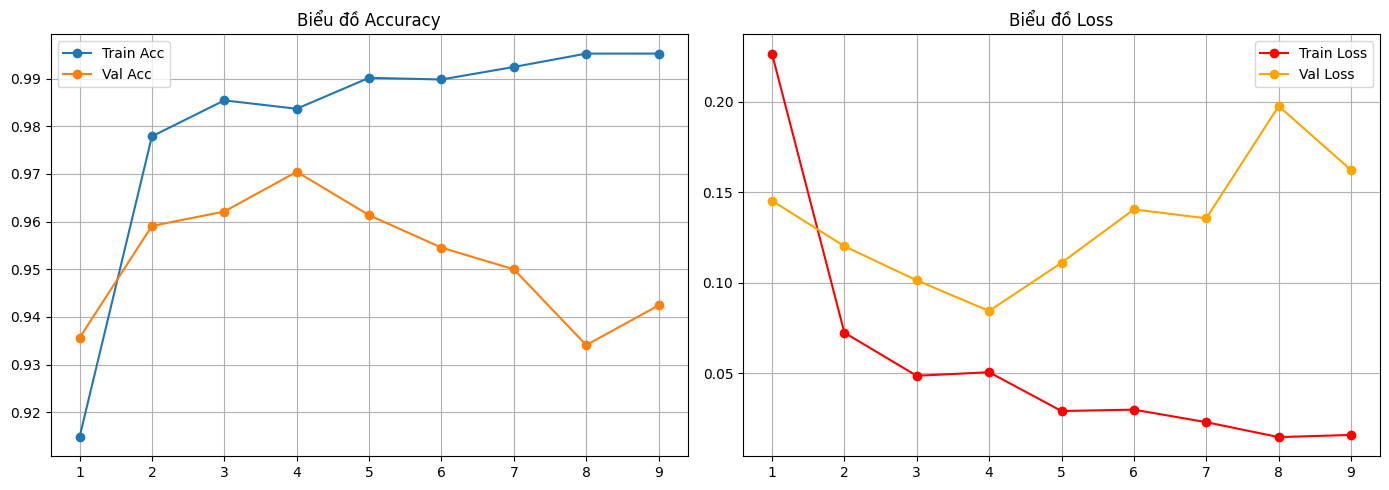

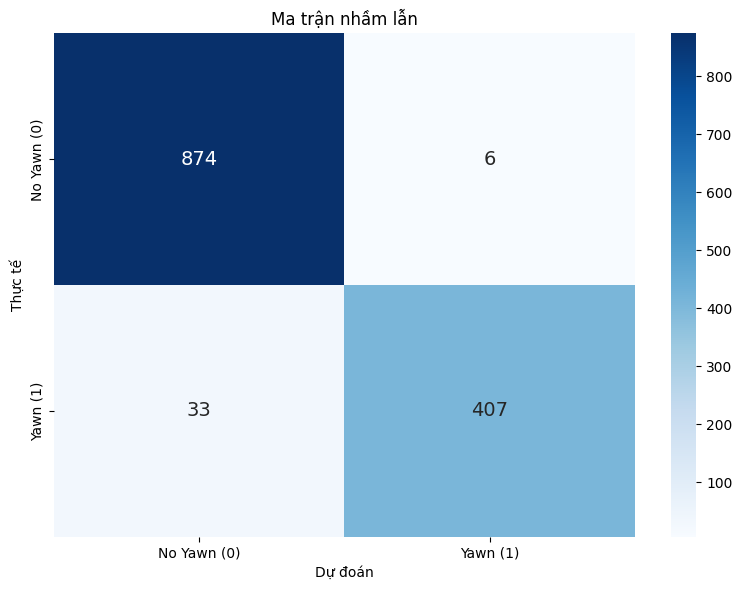

In [6]:
# 5. VẼ BIỂU ĐỒ
actual_epochs = len(history['train_acc'])
epochs_range = range(1, actual_epochs + 1)
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, history['train_acc'], label='Train Acc', marker='o')
plt.plot(epochs_range, history['val_acc'], label='Val Acc', marker='o')
plt.title('Biểu đồ Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history['train_loss'], label='Train Loss', marker='o', color='red')
plt.plot(epochs_range, history['val_loss'], label='Val Loss', marker='o', color='orange')
plt.title('Biểu đồ Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('training_charts_ultimate.png')

model.load_state_dict(torch.load('best_yawn_ultimate.pt', map_location=device))
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Yawn (0)', 'Yawn (1)'], 
            yticklabels=['No Yawn (0)', 'Yawn (1)'], annot_kws={"size": 14})
plt.title('Ma trận nhầm lẫn')
plt.ylabel('Thực tế')
plt.xlabel('Dự đoán')
plt.tight_layout()
plt.savefig('confusion_matrix_ultimate.png', dpi=300)
plt.show()